# Python crash course 

## Preface
All code that provided for the lectures and project walkthroughs will be provided as a classic Jupyter Notebook (like this one) primarily because (1) its markdown features (explained below) make it a great teaching platform and (2) it's python-based, which is very popular programming language in astronomy and planetary sciences. We recommend installing [Anaconda](https://www.anaconda.com/download) on your personal computer, which includes Python, Jupyter, Spyder, and several other tools you may find useful. Although, I guess if you're running this notebook as you read this, you may already have Anaconda installed... anyway...

This `crash course' is intended to give a broad overview of some useful commands and the primary Python packages used throughout the course and to serve as a reference and note-keeping tool. You are encouraged to make this notebook your own and add to it as you discover useful python functions throughout the course.

##### $\textbf{Disclaimer}$:
    
This is NOT a programming course. You are not expected to become programming experts. That being said, learning some useful programming skills IS a secondary goal of the course. As scientists you will need to sort/analyze (often large) data sets and make plots of the data which requires some degree of programming. 

In [1]:
import sys
import os
sys.path.insert(1, os.path.abspath('./functions'))
from nb_toc import toc, setup
setup()

toc(["Using the markdown feature in Jupyter",
    "Importing python packages",
    "Using a function",
    "Defining variables",
    "Handling arrays",
    "Plotting data",
    "How to make a GOOD plot!",
    "User-defined functions",
    "SciPy basics",
    "Figures with multiple panels"])

<IPython.core.display.Javascript object>

## Using the markdown feature in Jupyter
As mentioned in the preface, Jupyter Notebooks are a great teaching tools because of the markdown feature which allow you to include nicely formatted blocks of text. If you are reading this, then you are currently looking at a markdown cell. Jupyter notebook cells are set to 'code' by default. You can switch a cell to the markdown type by clicking on the far left of the cell and pressing 'm' or selecting Cell>Cell type>Markdown using the tool bar at the top.

You run cells using shift-enter. If you want to look at the underlying syntax of a markdown cell like this one, double click on it. To regenerate the nice, clean looking output, hit shift-enter when you are done making your edits.
    
You can create headers within a markdown cell via hashtags. Increasing the number of hashtags decreasing the size, or level, of the header like so:
   
# Header level 1
## Header level 2
### Header level 3
### Header level 4
#### so on and so fourth...

You can make bulleted lists by indenting the text and using a dash or asterisk followed by a space and then the item like so:
- some item
* some other item

Or, a numbered list like so:
1. first order of business
2. second order of business
3. third order of business

You can also make some nice equations. This feature uses LaTeX syntax. LaTeX is a programming-ish writing tool where your text is essentially embedded within a script that includes commands for formatting, generating equations, tables, figures, etc. LaTeX is used pretty widely for paper writing in astronomy and (exo)planetary sciences. Even if you don't use LaTeX on a daily basis, if you decide to pursue a career in astronomy/(exo)planetary science, it's worth learning the basics as you will almost certainly find yourself as a coauthor on a paper written using LaTeX.

Anyway, here is an example of an in-line equation $y = m \times x + b$. The two dollar signs tell the markdown cell that there is an equation in between them. You can also create a stand-alone, centered equation via double dollar signs

$$y = m \times x + b$$.

Here are some examples of some symbols and quantities we will encounter throughout the semester and how to call them in latex:

- Symbol for the Sun: $\odot$
- Symbol for Earth: $\oplus$
- Symbol for density: $\rho$
- 1 Earth mass = $5.972\times10^{27} \; \mathrm{kg} \equiv 1 M_\oplus$
- 1 Earth radius = $6371 \mathrm{km} \equiv 1 R_\oplus$
- 1 Earth density = $5515 \mathrm{\frac{kg}{m^3}} \equiv 1 \rho_\oplus$
- Average distance between the Sun and Earth = $1.496\times10^{11} \mathrm{m} \equiv 1 \mathrm{AU}$ 



## Importing python packages
The two main packages we will use throughout the course are NumPy for handling arrays (a.k.a. our data) and matplotlib.pyplot (which is designed to be MATLAB-like, hence the name) for visualization. To import a Python package, you simply type import package in a cell as shown below

In [4]:
import numpy
import matplotlib.pyplot

Now that these are imported, we can call functions or objects within NumPy or matplotlib.pyplot by typing their name. followed by the name of the function or object. You can make your life a bit easier by assigning packages a shorthand. The commonly used shorthand for NumPy is np and plt for matplotlib.pyplot. Instead of typing out the full name of either of these when you want to call a function, you can now just use 'np.function_name' or 'plt.function_name'. This probably doesn't save a ton of time for NumPy, but matplotlib.pyplot is super annoying to type out every. single. time. when you are doing some serious plottin'.


In [5]:
import numpy as np
import matplotlib.pyplot as plt

## Using a function
Let's now look at calling a useful function from numpy: linspace. Linspace returns an array of length 'num' from some 'start' number to a 'stop' number with num evenly space numbers. Take a look at the help page on numpy.linspace by checking out this link https://numpy.org/doc/stable/reference/generated/numpy.linspace.html or, even easier, typing ?np.linspace as shown below

In [6]:
?np.linspace

Signature:      
np.linspace(
    start,
    stop,
    num=50,
    endpoint=True,
    retstep=False,
    dtype=None,
    axis=0,
    *,
    device=None,
)
Call signature:  np.linspace(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function linspace at 0x10e8fa980>
File:            /opt/anaconda3/lib/python3.13/site-packages/numpy/_core/function_base.py
Docstring:      
Return evenly spaced numbers over a specified interval.

Returns `num` evenly spaced samples, calculated over the
interval [`start`, `stop`].

The endpoint of the interval can optionally be excluded.

.. versionchanged:: 1.16.0
    Non-scalar `start` and `stop` are now supported.

.. versionchanged:: 1.20.0
    Values are rounded towards ``-inf`` instead of ``0`` when an
    integer ``dtype`` is specified. The old behavior can
    still be obtained with ``np.linspace(start, stop, num).astype(int)``

Parameters
----------
start : array_like
    The starting value of the sequence.
stop : array

At the top of the help page you should see something that looks like
    
     np.linspace(start, stop, num = 50, endpoint=True, retstep=False, dtype=None, axis=0)
    
Everything to the right of the right parenthetical are the arguments for linspace. The 'start' and 'stop' arguments are required b/c there is no equal sign immediately after them. The remaining arguments are optional b/c there is an equal sign after them. For example the 'num' parameter reads 'num = 50' which, in plain English, says 'num is not required and if a value is not provided it will default to 50'. So, the command np.linspace(1, 5) will build me an array of 50 evenly spaced numbers from 1 to 5. Type this command in the cell below. Double check that the length of the array is indeed 50 by using the len function. The len function takes in an array or list and spits out its length, i.e., how many numbers it contains. It is a built-in python function, so there is no need to import a package to use it. Simply type len(np.linspace(1,5)) and run the cell. Your output should be 50.

If I just want the whole numbers between 1 and 5, I would need to change the num parameter to be 5. Try this in the cell below. Then check that the length of the array is indeed 5 by using the len function.

Another useful built in function in Python is the print funtion. If I don't use a print function in Jupyter, then only output of the last line of code will be printed when I run a cell. Try running the example below. 

In [7]:
np.linspace(1,5,5)
len(np.linspace(1,5,5))

5

Only the length of the array should be printed, not the array itself. If I wanted to print both, then I can put them both within print statements as shown below.

In [8]:
print(np.linspace(1,5,5))
print(len(np.linspace(1,5,5)))

[1. 2. 3. 4. 5.]
5


Some other useful commands to be aware of: ls and cwd
    
ls prints the files in your current directory and cwd prints the directory (folder) you are currently in. These won't help you analyze data or make nice plots, but they often help you get your barrings. If you are trying to load in a data file, for example, but you keep getting errors you don't understand, you may be/have: (1) not in the folder you think you are, (2) put your data in the wrong folder, (3) named your data file differently than you thought, or (4) loading in the data incorrectly. 

For issue 1, you would use cwd to see where you are. For issue 2 or 3, you could use ls to see if the data file is even there or named slightly differently than you thought (e.g., it contains an underscore or capitalized letters). For issue 4, check the help page for whatever data loading function you are using!
    
Try these out in the code cell below. 

## Defining variables 

Python makes it super easy to define variables. Unlike some other programming languages, you don't need to specify the variable type; python can infer it. So, all you need to do to define a variable is to type 'variable name = '. You can define a single value or a whole array. The cell below shows an example of a single-value variable 'a' which I have set to 2.0, a single-string variable 'b' which I have set to 'hello', and an array variable 'c' I set to the example from earlier.

In [9]:
a = 2.0
b = 'hello'
c = np.linspace(1,5,5)

print('variable a is: ', a)
print('variable b is: ', b)
print('vraiable c is: ', c)


variable a is:  2.0
variable b is:  hello
vraiable c is:  [1. 2. 3. 4. 5.]


You can also check whether a variable is an integer, a float, a string, etc. using the type function. You probably won't need it this semester, but it's still useful to be aware of especially if you are trying to figure out someone else's code or you are debugging your own. 

In [10]:
print('type of variable a: ', type(a))
print('type of variable b: ', type(b))
print('type of variable c: ', type(c))

type of variable a:  <class 'float'>
type of variable b:  <class 'str'>
type of variable c:  <class 'numpy.ndarray'>


## Handling arrays
Variable c above is an example of a NumPy array which are very useful. iirc, arrays in MATLAB are indexed starting with 1. In contrast, arrays in python are indexed starting with zero. I.e., if you want to get the first element of an array, you will need to type the name of the array immediately followed by [0] as shown below. 

In [11]:
c[0]

np.float64(1.0)

If, instead, you want the 2nd array element, you would use the index 1. Similarly, if you want the 3rd element, you would use [2]. Basically, c[i] will give you the i-th + 1 element of the array.

In [12]:
print('First element of array c = ', c[0])
print('Second element of array c = ', c[1])
print('Third element of array c = ', c[2])

First element of array c =  1.0
Second element of array c =  2.0
Third element of array c =  3.0


Below, is an array variable called arr that gives integers starting with 10 and decreasing to 0. 

In [13]:
arr = np.arange(11)[::-1]

In the cell below, use the 'arr' array to play around with indexing. What is the fifth element? What index should you use to get it?

## Loading data
There are many ways to load data in python. I like to save my data in csv format and use the read_csv function from the pandas package. You can accomplish the same thing using numpy.read_txt. There are pros and cons to both and I'll show examples with each. 

We are going to load in the file titled 'line_data.csv'. This is data for the line $y = 3x + 1$ from 0 to 1. I injected some scatter into the data using a standard Gaussian distribution with standard deviation of 3, i.e., $\mathcal{N}(0, 3)$. There are 100 data points.

### With pandas:

We first need to import the package

In [14]:
import pandas as pd

Now import the data using the pandas read_csv function and assign it a variable name. We can use the print function to look at the data and see if it imported like we expected.

In [15]:
line_data = pd.read_csv('./data/line_data.csv')
print(line_data)

           x         y
0   0.000000  0.833594
1   0.010101  1.005634
2   0.020202  2.091676
3   0.030303  1.005025
4   0.040404  1.121027
..       ...       ...
95  0.959596  3.672533
96  0.969697  3.755212
97  0.979798  3.973298
98  0.989899  3.699126
99  1.000000  4.024391

[100 rows x 2 columns]


Pandas is nice because it infers the column names and creates an object for each column which you can call via its name. For example, if you want to look at just the x values of the `line_data' data frame, you would do...

In [16]:
line_data['x']

0     0.000000
1     0.010101
2     0.020202
3     0.030303
4     0.040404
        ...   
95    0.959596
96    0.969697
97    0.979798
98    0.989899
99    1.000000
Name: x, Length: 100, dtype: float64

We can also use our friend the len function to check how many data points there are

In [17]:
len(line_data)

100

### With NumPy:

NumPy should already be imported, so there is no need to import it again. Unlike pd.read_csv, the loadtxt function cannot infer column names, so you have to tell it to skip the first row (if it contains the column names) otherwise it will yell at you. You also need to specify that the delimiter is a comma since we are loading in a csv file and numpy.loadtxt is set up for txt files by default.

In [18]:
line_data = np.loadtxt('./data/line_data.csv', skiprows = 1, delimiter = ',')
print(line_data)

[[0.         0.83359418]
 [0.01010101 1.00563418]
 [0.02020202 2.09167611]
 [0.03030303 1.00502501]
 [0.04040404 1.12102708]
 [0.05050505 0.95562954]
 [0.06060606 1.62669334]
 [0.07070707 1.0101457 ]
 [0.08080808 1.22854227]
 [0.09090909 1.61705193]
 [0.1010101  1.57845639]
 [0.11111111 1.83267315]
 [0.12121212 1.18007989]
 [0.13131313 1.48248865]
 [0.14141414 1.58120323]
 [0.15151515 1.38496749]
 [0.16161616 1.60651188]
 [0.17171717 1.35193924]
 [0.18181818 1.54405615]
 [0.19191919 1.68862259]
 [0.2020202  1.03116956]
 [0.21212121 2.1322966 ]
 [0.22222222 1.84816891]
 [0.23232323 1.69813355]
 [0.24242424 1.13559138]
 [0.25252525 1.42589227]
 [0.26262626 1.83769677]
 [0.27272727 1.86184354]
 [0.28282828 2.06825506]
 [0.29292929 1.16380465]
 [0.3030303  2.09446039]
 [0.31313131 1.34972083]
 [0.32323232 2.18939219]
 [0.33333333 2.15017048]
 [0.34343434 2.24259477]
 [0.35353535 1.94786288]
 [0.36363636 1.92080966]
 [0.37373737 2.19480807]
 [0.38383838 1.6907346 ]
 [0.39393939 2.63877357]


The nice thing about loadtxt is that it loads the data in directly as a numpy array object and so it should 'just work' with any numpy functions. The con is that there are no column names, so you need to know that the first column is your x data and the second column is your y data. Let's make our lives a bit easier by making an x variable containing the x data and a y variable containing the y data. Discuss the cell below with your group. What do the indices mean? What is the colon??

In [19]:
x = line_data[:,0]
y = line_data[:,1]

## Plotting data
Let's plot the x and y data we just imported using the plot function from matplotlib.pyplot. You can accomplish this by doing plt.plot(x,y,'ko'). The 'ko' arguement specifies that data points are to be plotted as black circles. This is an optional parameter. The default is to plot as a blue line. Confirm this by removing that arguement and rerunning the cell below. You try some other colors out to by changing the k to c for cyan, m for magenta, b for blue, g from green and many more. Similarly, you can change the shape of the data points by changing the o to an s for squares, * for stars, ^ for triangle, etc. 

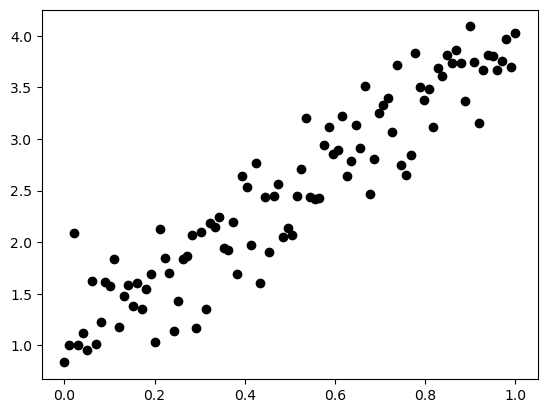

In [20]:
plt.plot(x, y, 'ko')

The above plot is, well..., a plot. But, it is pretty uninformative. So, let's discuss ...

## How to make a GOOD plot!

Let's first start with the why. Why spend the time to create a good figure? They're generally one of the first things someone looks at when reading/skimming a paper. A common approach is to start with the abstract and then look through the figures before deciding whether to spend the time to read a document in full. As such, the reader should be able to get a good picture of your paper/report by just reading the abstract and looking at the figures.

A 'good plot' is somewhat subjective and you will see lots of different examples in papers of plots that are good (and just as many bad ones!). You will also develop your own personal style/color palate/etc. as you make more and more plots. That being said, at a bare minimum a good figure should:

1. Have large, informative axis labels WITH THE APPROPRIATE UNITS.
2. Have smaller but still large, legable tick labels. Your tick spacing should have a reasonable resolution relative to the data you are presenting. You should generally include both major and minor ticks. The minor ticks will not be labeled, but will allow the reader to pinpoint the x and y values of a given data point more precisely.
3. Be [color-blind friendly](https://davidmathlogic.com/colorblind/#%23D81B60-%231E88E5-%23FFC107-%23004D40) and easy for the viewer to distinguish between the elements in the plot, especially if you are plotting multiple data sets or trying to highlight various subgroups within a single data set, e.g., plotting planets discovered by different techniques like shown [here](https://exoplanetarchive.ipac.caltech.edu/ScatterPlot/?config=scatter&table=PS_output.csv&columns=PS_columns.tbl&theme=pres&x=pl_orbper&y=pl_bmassj&symbol-color=discoverymethod&symbol-size-min=8&legendpos=bottomright&pregen=png).
4. Have a legend! You need to tell the reader what the various symbols/lines/objects in the figure are. You should also include a description of these in the figure caption, but don't make/expect the reader to go digging for that information.
5. A concise but descriptive figure caption. Figure captions will generally be added in whatever word processor you are using. Since this isn't coding related, it falls outside the scope of this notebook.
6. Show something meaningful! This may sound obvious, but as you work through a project in this class or outside of it, you will likely make a LOT more plots/figures than what will go in the final report/paper. You do not want to inundate the reader with uninformative or unimportant plots. You want to only display your key findings! 

Including a title above the figure is a good rule of thumb, but not always necessary. Usually, the first bit of the caption will serve as an effective figure title.

OK -- the code cell below will generate a somewhat better version of the figure above applying some of the outlined principles. Take a close look at this new figure. Think about what is/isn't included and what improvements could be made. Google around and try to add those things. Feel free to come up with more realistic names for the x and y data.

(0.75, 4.25)

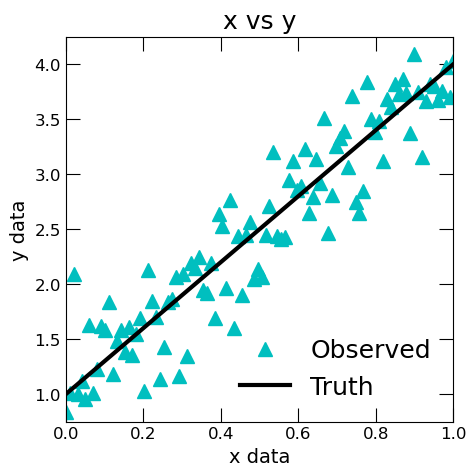

In [22]:
plt.figure(figsize = (5,5))
plt.plot(x,y, 'c^', label = 'Observed', markersize = 10)
plt.plot(x, 3.0*x + 1.0, 'k-', label = 'Truth', linewidth = 3)

plt.legend(fontsize = 18, frameon = False, loc = 'lower right')
plt.tick_params(labelsize = 12, direction = 'in', top = True, right = True, length = 10)

plt.xlabel('x data', fontsize = 14)
plt.ylabel('y data', fontsize = 14)
plt.title('x vs y', fontsize = 18)
plt.xlim(0, 1)
plt.ylim(0.75, 4.25)



## User-defined functions
We can also define our own functions as

def function_name(arguements):
    some operation using the arguements
    return a number, a list of numbers, an array, or something else

For example, we can define a function for a line which will return an array of the y values.

In [23]:
def my_line(x, m, b):
    return x*m + b

Once the line function is defined, we can reproduce the y-values above by just doing something like the cell below. Using "x", "m", and "b" work fine for the purposes of this crash course, but when you are handling real data, it is good practice to use more informative names! Uninformative names quickly become tough to keep track of in larger code and tend to get overwritten. This can be an absolute pain for debugging, because overwriting an existing variable is not technically wrong, so you won't get an error.

In [24]:
my_line(x, 3.0, 1.0)

array([1.        , 1.03030303, 1.06060606, 1.09090909, 1.12121212,
       1.15151515, 1.18181818, 1.21212121, 1.24242424, 1.27272727,
       1.3030303 , 1.33333333, 1.36363636, 1.39393939, 1.42424242,
       1.45454545, 1.48484848, 1.51515152, 1.54545455, 1.57575758,
       1.60606061, 1.63636364, 1.66666667, 1.6969697 , 1.72727273,
       1.75757576, 1.78787879, 1.81818182, 1.84848485, 1.87878788,
       1.90909091, 1.93939394, 1.96969697, 2.        , 2.03030303,
       2.06060606, 2.09090909, 2.12121212, 2.15151515, 2.18181818,
       2.21212121, 2.24242424, 2.27272727, 2.3030303 , 2.33333333,
       2.36363636, 2.39393939, 2.42424242, 2.45454545, 2.48484849,
       2.51515152, 2.54545455, 2.57575758, 2.60606061, 2.63636364,
       2.66666667, 2.6969697 , 2.72727273, 2.75757576, 2.78787879,
       2.81818182, 2.84848485, 2.87878788, 2.90909091, 2.93939394,
       2.96969697, 3.        , 3.03030303, 3.06060606, 3.09090909,
       3.12121212, 3.15151515, 3.18181818, 3.21212121, 3.24242

You can also do any number of operations within the user defined function. Any variables you define within the function will remain local to the function. Maybe we want to define a function to do the plotting above so we can reuse it over and over. Also, you can specify optional parameters by adding an = after the variable in the function definition, like the xrange and yrange parameters below. Whatever you specify will be the default for the optional parameter. 

Optional inputs must come AFTER the required function inputs.

In [25]:
def plot_line(x, m, b, xrange = [0, 1], yrange = [0.75, 4.25] ):

    fig = plt.figure(figsize = (5,5))
    plt.plot(x, y, 'c^', label = 'Observed', markersize = 10)
    plt.plot(x, 3.0*x + 1.0, 'k-', label = 'Truth', linewidth = 3)
    
    plt.legend(fontsize = 18, frameon = False, loc = 'lower right')
    plt.tick_params(labelsize = 18, direction = 'in', top = True, right = True, length = 10)
    
    plt.xlabel('x data', fontsize = 24)
    plt.ylabel('y data', fontsize = 24)
    plt.title('x vs y', fontsize = 32)
    plt.xlim(xrange[0], xrange[1])
    plt.ylim(yrange[0], yrange[1])


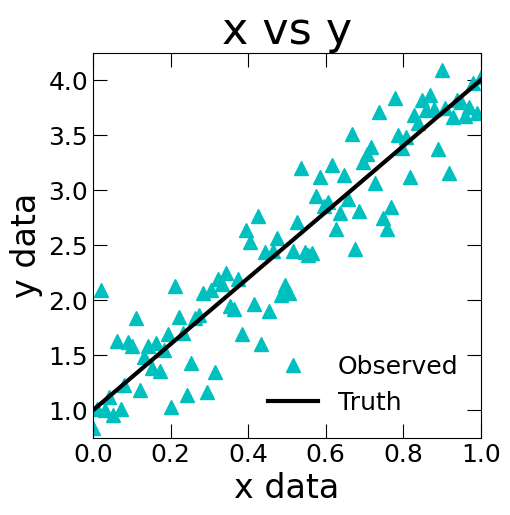

In [26]:
plot_line(x, 3.0, 1.0)

## Classes
Another nice thing about python is the ability to define classes, which can group together any number of parameters, arrays, datatypes, etc. The example below is a bit contrived, but we can set up a class for our line that will allow us to calculate the y values for the line without having to specify m and y0 over and over. Similarly, we can also add in the plotting function in a way that doesn't require us to specify all the plotting parameters over and over again. We can take it a step further and nest classes to separate different types of variables/functions/what not depending on the level of orginization we want. 

The base class below is "my_line" and contains two subclasses: "line_params" which contain y0 and m and "plot_params" which contain the plotting limits

In [27]:
class my_line:

    line_data = np.loadtxt('./data/line_data.csv', skiprows = 1, delimiter = ',')
    
    class line_params:
        x = np.linspace(1,5,50)
        m = 3.0
        y0 = 1.0

    class plot_params:
        xrange = [0, 1]
        yrange = [0.75, 4.25] 


        
    def calc_y(x):
        return my_line.line_params.m*x + my_line.line_params.y0

    def plot_line():
        fig = plt.figure(figsize = (5,5))
        plt.plot(my_line.line_data[:,0], my_line.line_data[:,1], 'c^', label = 'Observed', markersize = 10)
        plt.plot(my_line.line_data[:,0], my_line.calc_y(line_data[:,0]), 'k-', label = 'Truth', linewidth = 3)
        
        plt.legend(fontsize = 18, frameon = False, loc = 'lower right')
        plt.tick_params(labelsize = 18, direction = 'in', top = True, right = True, length = 10)
        
        plt.xlabel('x data', fontsize = 24)
        plt.ylabel('y data', fontsize = 24)
        plt.title('x vs y', fontsize = 32)
        plt.xlim(my_line.plot_params.xrange)
        plt.ylim(my_line.plot_params.yrange)


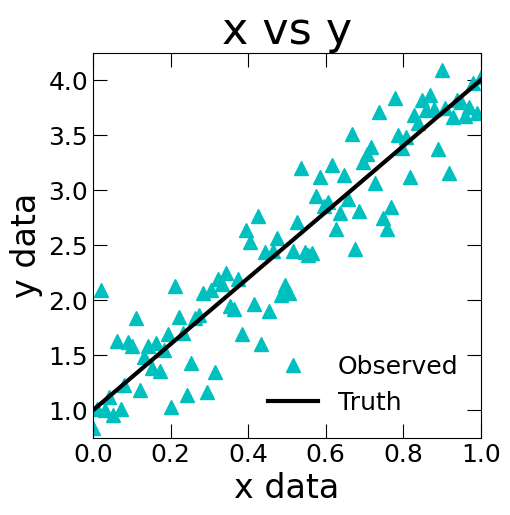

In [28]:
my_line.plot_line()

## SciPy basics

SciPy is an extremely useful python package for various statistical techniques like generating random samples from a known distribution, fitting user-defined functions to data, solving for the roots of a function, and much more!

There is no way to encompass all that SciPy has to offer here. Instead, we'll use a contrived example to demonstrate some common SciPy functions that you may find useful in this course.

You're a cat scientist and you want to explore what dependence other cat-related parameters and behaviors have on overall cat length (nose to tail). So, you (somehow) gather a group of 100 cats and measure a whole swath of things. You find only two of the parameters have any meaningful correlation with cat length: average number of meows per hour and cat weight. Since we can't realistically go gather a group of 100 cats during class, I've used a few SciPy functions to simulate the data instead. Namely, functions within the statistics module called `random variates of a given size', or rvs, which generate a give number of random samples from an a priori specific distribution. In this example, we are using normal (norm) and uniform distributions, but SciPy has a lot more that you can pick from!



In [29]:
import scipy as sp

# We have a sample of 30 cats!
number_of_cats = 100

# Randomly assign a length to each of the 30 cats assuming a uniform distribution of cat lengths in our sample 
# (probably not realistic for cats, but this is a made up experiment).
cat_length_values = sp.stats.uniform.rvs(5, 25, size = number_of_cats)

#randomly sample a variance value for each cats weight and moews per hour
var_meows_per_hour = sp.stats.norm.rvs(0, 1, size = number_of_cats)
var_in_weight = sp.stats.norm.rvs(0, 2, size = number_of_cats)

# I'm modeling the number of meows per hour using an exponential decay such that shorter cats are generally more talkative, 
# with a steep decline the larger the cat.
def meows_as_a_function_of_length(cat_length, y0 = 20.0, k=0.1):
    return y0-np.exp(k*cat_length)

# Assuming a linear relationship between cat length and its weight assuming a conversion factor of 0.5 pounds per inch of length.
def weight_as_a_function_of_length(cat_length, ppi = 0.5):
    return ppi*cat_length

# Now calculate each cats' average meows per hour (or mph, if you will) and weight accounting for the cat-cat variances in each!
meows_per_hour_values = meows_as_a_function_of_length(cat_length_values) + var_meows_per_hour
weight_values = weight_as_a_function_of_length(cat_length_values) + var_in_weight


Now that we have the data in hand, we can also use scipy to fit the data if we have a function in mind, which we already do since we just generated the data. So, let's go ahead and find the best-fit parameters for the functions defined in the previous cell. To this end, we can call the curve_fit function within SciPy's optimize module. 

$\textbf{Disclaimer}$: it's a bit weird/circular to fit the same functions to the data used to generate them. However, you generally won't be generating your own data! Rather, you'll already have a physically motivated function in mind that you want to fit to the data. In which case, you could follow the same procedure below, just with your own user-defined functions.

In [30]:
fit_params_meows_per_hour = sp.optimize.curve_fit(meows_as_a_function_of_length, cat_length_values, meows_per_hour_values)
fit_params_weight = sp.optimize.curve_fit(weight_as_a_function_of_length, cat_length_values, weight_values)


print('Meows per hour = ', round(fit_params_meows_per_hour[0][0], 3), 
      '(+/-', round(np.sqrt(fit_params_meows_per_hour[1][0,0]), 3) ,')',
      '- EXP[', round(fit_params_meows_per_hour[0][1], 3), 
      '(+/-', round(np.sqrt(fit_params_meows_per_hour[1][1,1]), 3) ,')',
      'x (length of cat / inches)]')

print('Weight [pounds] = ', round(fit_params_weight[0][0], 3), 
      '(+/-', round(np.sqrt(fit_params_weight[1][0,0]), 3) ,')',
      'x (length of cat / inches)')

Meows per hour =  19.956 (+/- 0.134 ) - EXP[ 0.1 (+/- 0.001 ) x (length of cat / inches)]
Weight [pounds] =  0.5 (+/- 0.01 ) x (length of cat / inches)


## Figures with multiple panels

As you work through a project and go to plot your results like discussed earlier, you may find that one panel just doesn't cut it for a figure. In our cat example, it likely wouldn't make much sense to plot Meows per hour vs cat length and weight vs cat length as two separate figures since they both depend on the same independent variable. Fortunately, creating a figure with multiple subplots is reasonably straightforward to do with matplotlib and below is an example of the simplest way using the plt.subplot function in the code cell below. Discuss what each line is doing and don't be afraid to pull up the help pages for the various functions!

$\textbf{Tip}$: If you need some more freedom to change the size of each individual subplot check out plt.subplot2grid. It's somewhat clunkier, but gives you a lot more room to customize the subplot layout. 


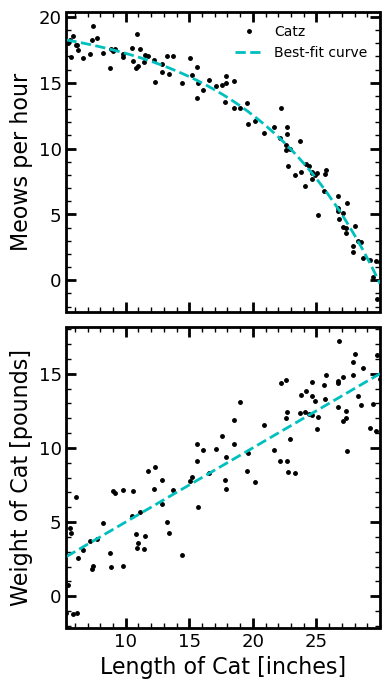

In [31]:
# First define some global variables that will carry from one subplot to the next so their presentation is consistent, and so that you
# don't have to go through line by line if you want to change something like the axis label sizes.
axis_label_size = 16
tick_label_size = 13

data_color = 'k'
data_symbol = '.'
data_linestyle = 'none'
data_label = 'Catz'
data_marker_size = 5

line_fit_color = 'c'
line_fit_style = '--'
linewidth = 2
line_fit_label = 'Best-fit curve'

xrange = (min(cat_length_values), max(cat_length_values))
major_tick_spacing = 5
minor_tick_spacing = 1

# initialize the figure
fig, ax = plt.subplots(2,1, figsize = (4,7))
from matplotlib.ticker import MultipleLocator

#-------------code for the top subplot---------------#
# Plot the raw data
ax[0].plot(cat_length_values, meows_per_hour_values, color = data_color, marker = data_symbol, 
           markersize = data_marker_size, linestyle = data_linestyle, label = data_label)
# Plot the associated function with the best-fit parameters
ax[0].plot(np.sort(cat_length_values), 
           meows_as_a_function_of_length(np.sort(cat_length_values), y0 = fit_params_meows_per_hour[0][0], k = fit_params_meows_per_hour[0][1]),
           linestyle = line_fit_style,
           color = line_fit_color,
           linewidth = linewidth, label = line_fit_label)
ax[0].set_xlim(xrange)

ax[0].legend(loc = 'upper right', frameon = False)

ax[0].tick_params(which = 'major', direction = 'in', top = True, right = True, length = 7, width = 2, 
                  labelsize = tick_label_size, labelbottom = False)
ax[0].tick_params(which = 'minor', direction = 'in', top = True, right = True, length = 3.5, width = 1)

ax[0].yaxis.set_major_locator(MultipleLocator(major_tick_spacing))
ax[0].yaxis.set_minor_locator(MultipleLocator(minor_tick_spacing))

ax[0].xaxis.set_major_locator(MultipleLocator(major_tick_spacing))
ax[0].xaxis.set_minor_locator(MultipleLocator(minor_tick_spacing))

ax[0].patch.set_edgecolor('black')  
ax[0].patch.set_linewidth(2) 

ax[0].set_ylabel('Meows per hour', fontsize = axis_label_size)

#----------------------------------------------------#
#-------------code for the bottom subplot---------------#
ax[1].plot(cat_length_values, weight_values, color = data_color, marker = data_symbol, 
           markersize = data_marker_size, linestyle = data_linestyle, label = data_label)
ax[1].plot(np.sort(cat_length_values), 
           weight_as_a_function_of_length(np.sort(cat_length_values), ppi = fit_params_weight[0]),
           linestyle = line_fit_style,
           color = line_fit_color,
           linewidth = linewidth)
ax[1].set_xlim(xrange)

ax[1].tick_params(which = 'major', direction = 'in', top = True, right = True, length = 7, width = 2, labelsize = tick_label_size)
ax[1].tick_params(which = 'minor', direction = 'in', top = True, right = True, length = 3.5, width = 1)

ax[1].yaxis.set_major_locator(MultipleLocator(major_tick_spacing))
ax[1].yaxis.set_minor_locator(MultipleLocator(minor_tick_spacing))

ax[1].xaxis.set_major_locator(MultipleLocator(major_tick_spacing))
ax[1].xaxis.set_minor_locator(MultipleLocator(minor_tick_spacing))

ax[1].patch.set_edgecolor('black')  
ax[1].patch.set_linewidth(2) 
ax[1].set_ylabel('Weight of Cat [pounds]', fontsize = axis_label_size)
ax[1].set_xlabel('Length of Cat [inches]', fontsize = axis_label_size)

#----------------------------------------------------#
#-------------------Save it!!!-----------------------#
# this next line just pulls the plot elements in closer, which usually makes it look a bit cleaner.
plt.tight_layout()

# You want to make sure the figure isn't massive in size, but also that it has enough resolution so that when the reader
# zooms in it doesn't become blurry. This can be a bit of trial and error. A dots per inch (dpi) of 300 is usually a good place to start.
plt.savefig('my_catz_plot.png', dpi = 300)



Alright that's ALL for now. The next couple cells are mostly just for fun, but you might find some uses for them in the nebulous future. 

One fun thing you can do is add images to plots! For example you may want to add pictures of the Solar System planets to plots you plan to use for an upcoming talk/poster. Here, let's say we want to point out a couple cats that have a statistically abnormal number of toe beans relative to the other cats for whatever reason (use your imagination!). In the figures folder, there is a file called 'cat.svg'. This is just a cat face pulled from Adobe Stock (which you should have access to through LSU) converted it to a Scalable Vector Graphics (svg) format. We can call this figure and create a symbol from it, but we'll need two additional packages that aren't including in the Anaconda distribution. The command in the cell below should install these packages on your machine.

In [32]:
pip install svgpathtools svgpath2mpl

Note: you may need to restart the kernel to use updated packages.


In [33]:
import matplotlib as mpl
from svgpathtools import svg2paths
from svgpath2mpl import parse_path

cat_path, attributes = svg2paths('./figures/cat.svg')
cat_marker = parse_path(attributes[0]['d'])
cat_marker.vertices -= cat_marker.vertices.mean(axis=0)
cat_marker = cat_marker.transformed(mpl.transforms.Affine2D().rotate_deg(180))

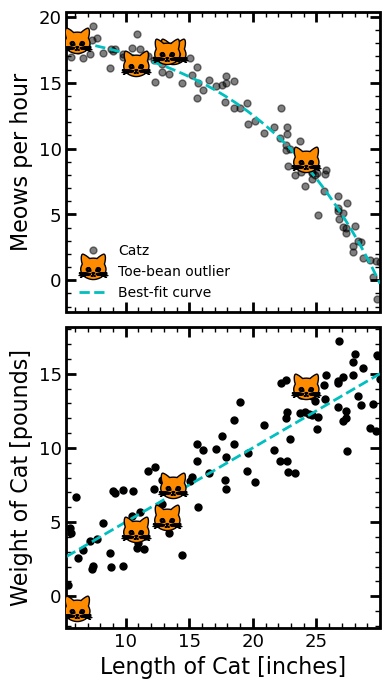

In [34]:
# First define some global variables that will carry from one subplot to the next so their presentation is consistent, and so that you
# don't have to go through line by line if you want to change something like the axis label sizes.
axis_label_size = 16
tick_label_size = 13

data_color = 'k'
data_symbol = '.'
data_linestyle = 'none'
data_label = 'Catz'
data_marker_size = 10
data_marker_alpha = 0.5

cat_marker_color = 'darkorange'
cat_marker_edgecolor = 'k'
cat_marker_alpha = 1
cat_marker_size = 2.5*data_marker_size


line_fit_color = 'c'
line_fit_style = '--'
linewidth = 2
line_fit_label = 'Best-fit curve'

xrange = (min(cat_length_values), max(cat_length_values))
major_tick_spacing = 5
minor_tick_spacing = 1

# pick out five random cats to serve as the anomalous toe-bean cats
toe_bean_outliers = np.random.randint(0, len(cat_length_values)-1, 5)

# initialize the figure
fig, ax = plt.subplots(2,1, figsize = (4,7))
from matplotlib.ticker import MultipleLocator

#-------------code for the top subplot---------------#
# Plot the raw data
ax[0].plot(cat_length_values, meows_per_hour_values, color = data_color, marker = data_symbol, 
           markersize = data_marker_size, linestyle = data_linestyle, label = data_label, alpha = data_marker_alpha)
# plot the toe-bean outliers with the cat symbol
ax[0].plot(cat_length_values[toe_bean_outliers], meows_per_hour_values[toe_bean_outliers], marker = cat_marker, color = cat_marker_color,
           markersize = cat_marker_size, linestyle = data_linestyle, zorder = 5, 
           alpha = cat_marker_alpha, markeredgecolor = cat_marker_edgecolor, label = 'Toe-bean outlier')

# Plot the associated function with the best-fit parameters
ax[0].plot(np.sort(cat_length_values), 
           meows_as_a_function_of_length(np.sort(cat_length_values), y0 = fit_params_meows_per_hour[0][0], k = fit_params_meows_per_hour[0][1]),
           linestyle = line_fit_style,
           color = line_fit_color,
           linewidth = linewidth, label = line_fit_label)
ax[0].set_xlim(xrange)

ax[0].legend(loc = 'lower left', frameon = False)

ax[0].tick_params(which = 'major', direction = 'in', top = True, right = True, length = 7, width = 2, 
                  labelsize = tick_label_size, labelbottom = False)
ax[0].tick_params(which = 'minor', direction = 'in', top = True, right = True, length = 3.5, width = 1)

ax[0].yaxis.set_major_locator(MultipleLocator(major_tick_spacing))
ax[0].yaxis.set_minor_locator(MultipleLocator(minor_tick_spacing))

ax[0].xaxis.set_major_locator(MultipleLocator(major_tick_spacing))
ax[0].xaxis.set_minor_locator(MultipleLocator(minor_tick_spacing))

ax[0].patch.set_edgecolor('black')  
ax[0].patch.set_linewidth(2) 

ax[0].set_ylabel('Meows per hour', fontsize = axis_label_size)

#----------------------------------------------------#
#-------------code for the bottom subplot---------------#
ax[1].plot(cat_length_values, weight_values, color = data_color, marker = data_symbol, 
           markersize = data_marker_size, linestyle = data_linestyle, label = data_label, alpha = cat_marker_alpha)
ax[1].plot(cat_length_values[toe_bean_outliers], weight_values[toe_bean_outliers], marker = cat_marker, color = cat_marker_color,
           markersize = cat_marker_size, linestyle = data_linestyle, zorder = 5, 
           alpha = cat_marker_alpha, markeredgecolor = cat_marker_edgecolor)

ax[1].plot(np.sort(cat_length_values), 
           weight_as_a_function_of_length(np.sort(cat_length_values), ppi = fit_params_weight[0]),
           linestyle = line_fit_style,
           color = line_fit_color,
           linewidth = linewidth)
ax[1].set_xlim(xrange)

ax[1].tick_params(which = 'major', direction = 'in', top = True, right = True, length = 7, width = 2, labelsize = tick_label_size)
ax[1].tick_params(which = 'minor', direction = 'in', top = True, right = True, length = 3.5, width = 1)

ax[1].yaxis.set_major_locator(MultipleLocator(major_tick_spacing))
ax[1].yaxis.set_minor_locator(MultipleLocator(minor_tick_spacing))

ax[1].xaxis.set_major_locator(MultipleLocator(major_tick_spacing))
ax[1].xaxis.set_minor_locator(MultipleLocator(minor_tick_spacing))

ax[1].patch.set_edgecolor('black')  
ax[1].patch.set_linewidth(2) 
ax[1].set_ylabel('Weight of Cat [pounds]', fontsize = axis_label_size)
ax[1].set_xlabel('Length of Cat [inches]', fontsize = axis_label_size)

#----------------------------------------------------#
#-------------------Save it!!!-----------------------#
# this next line just pulls the plot elements in closer, which usually makes it look a bit cleaner.
plt.tight_layout()

# You want to make sure the figure isn't massive in size, but also that it has enough resolution so that when the reader
# zooms in it doesn't become blurry. This can be a bit of trial and error. A dots per inch (dpi) of 300 is usually a good place to start.
plt.savefig('my_catz_plot_number_2.png', dpi = 300)

## Some other things you can try
If you've reached this point of the notebook, it's time to do some exploring on your own. The ideas below are just intended to get you thinking and relate to the NASA Exoplanet Archive (NEA) and the Hypatia Catalog, both of which you will use a LOT this semester and have plots/outputs you can vet your code against. You should feel free to come up with your own ideas, too!

Use the astroquery package to pull data directly from the NEA using its [Table Access Protocol (TAP) service](https://exoplanetarchive.ipac.caltech.edu/docs/TAP/usingTAP.html). It's relatively straightforward to download a new dataset from the NEA website. However, if you find yourself doing this a lot, it can start to get annoying to pull a new file and then having to update a bunch of code that calls the old, outdated file (been there, done that, don't recommend). Incorporating the TAP query into the code will insure you get the most up-to-date exoplanet data everytime you run the code without having to think about it.

Try to reproduce some of the [pregenerated plots](https://exoplanetarchive.ipac.caltech.edu/exoplanetplots/) on the [NASA Exoplanet Archive](https://exoplanetarchive.ipac.caltech.edu/index.html). You already saw some of these figures in the first lecture. And you will be seeing a lot more of them, and making your own versions of them throughout the semester, so might as well get started now!

Interact with the [Hypatia Catalog](https://hypatiacatalog.com/hypatia) using its [Application Programming Interface](https://hypatiacatalog.com/api). There is a TON of cool stuff you can do with Hypatia. For starters, maybe try making a plot similar to Fig. 6 of [Lodders 2009](https://arxiv.org/pdf/0901.1149). Alternatively, you can try reproducing any number of the stellar abundance scatter plots possible through [Hypatia's interactive plotting feature](https://hypatiacatalog.com/hypatia/default/launch).
    